<a href="https://colab.research.google.com/github/Urpia-S/Olist_E-commerce_Analytic-SQL-Python/blob/main/notebooks/06_playground_consultas_sql_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06 - Playground SQL

Este notebook fica como espaco livre para testar consultas novas sobre o `olist_colab.sqlite`.

In [1]:
from pathlib import Path
import sqlite3
import urllib.request
import zipfile

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)

PROJECT_DIR = Path.cwd()
DB_ZIP_URL = "https://github.com/Urpia-S/Olist_E-commerce_Analytic-SQL-Python/releases/download/data-v1/olist_colab.sqlite.zip"
DB_PATH = PROJECT_DIR / "olist_colab.sqlite"


def baixar_banco_da_release():
    zip_path = PROJECT_DIR / "olist_colab.sqlite.zip"
    urllib.request.urlretrieve(DB_ZIP_URL, zip_path)

    with zipfile.ZipFile(zip_path) as archive:
        archive.extractall(PROJECT_DIR)

    print("Banco extraido em:", DB_PATH)


if not DB_PATH.exists():
    baixar_banco_da_release()

conn = sqlite3.connect(DB_PATH)


def consulta(sql):
    return pd.read_sql_query(sql, conn)

Banco extraido em: /content/olist_colab.sqlite


## Tabelas e views disponiveis

Lista rapida para lembrar os objetos criados no banco.

In [2]:
consulta("""
-- Objetos disponiveis no SQLite.
SELECT
    type AS tipo,
    name AS nome
FROM sqlite_master
WHERE type IN ('table', 'view')
ORDER BY type, name;
""")

,tipo,nome
0,table,core_customers
1,table,core_geolocation_zip_city
2,table,core_order_items
3,table,core_order_payments
4,table,core_order_reviews
5,table,core_orders
6,table,core_product_category_translation
7,table,core_products
8,table,core_sellers
9,table,stg_customers


## Exemplo 1: cidades com mais pedidos

In [3]:
cidades = consulta("""
-- Cidades com maior quantidade de pedidos.
SELECT
    c.customer_city,
    c.customer_state,
    COUNT(DISTINCT o.order_id) AS pedidos
FROM core_orders o
JOIN core_customers c ON c.customer_id = o.customer_id
GROUP BY c.customer_city, c.customer_state
ORDER BY pedidos DESC
LIMIT 15;
""")

cidades

,customer_city,customer_state,pedidos
0,sao paulo,SP,15540
1,rio de janeiro,RJ,6882
2,belo horizonte,MG,2773
3,brasilia,DF,2131
4,curitiba,PR,1521
5,campinas,SP,1444
6,porto alegre,RS,1379
7,salvador,BA,1245
8,guarulhos,SP,1189
9,sao bernardo do campo,SP,938


## Exemplo 2: comentarios negativos

In [4]:
consulta("""
-- Exemplos de comentarios negativos para leitura qualitativa.
SELECT
    review_score,
    review_comment_title,
    review_comment_message
FROM core_order_reviews
WHERE review_score IN (1, 2)
  AND review_comment_message IS NOT NULL
LIMIT 20;
""")

,review_score,review_comment_title,review_comment_message
0,1,None,Na descrição do produto quando fui efetuar a c...
1,1,produto não entregue,Mudo minha opinião assim que receber o produto...
2,1,None,nao recebi o produto
3,1,None,Entrega muito demorada. Ainda não recebi o pro...
4,1,None,Entrega prometida 24/05/17. Dia 26/05/17 não h...
5,1,Pessima,O produto chegou e estragou sozinho
6,1,None,"Comprei dois produtos no mesmo dia, sexta-feir..."
7,1,None,Comprei duas mochilas e recebi somente um prod...
8,2,Mesa com cavaletes,"Demora absurda para entrega, dentro do prazo e..."
9,1,None,"O relógio, (presente do dia das crianças pra m..."


## Exemplo 3: media movel mensal de receita

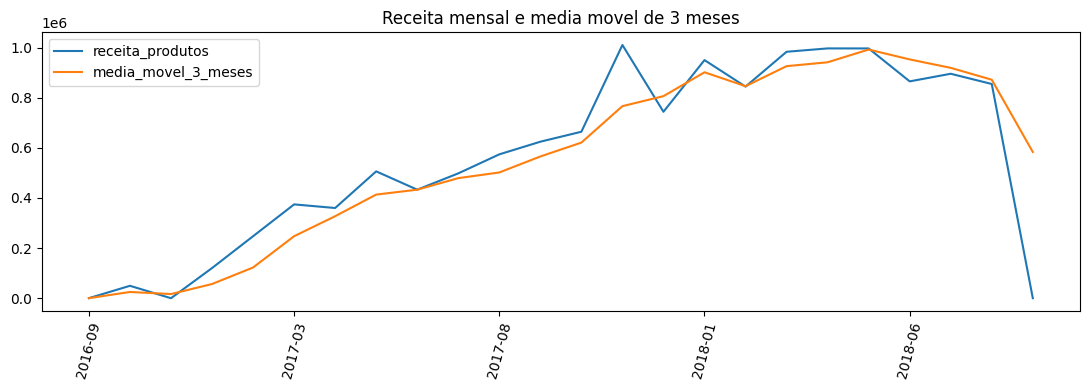

,mes_pedido,receita_produtos,media_movel_3_meses
19,2018-05,996517.68,992126.29
20,2018-06,865124.31,952763.25
21,2018-07,895507.22,919049.74
22,2018-08,854686.33,871772.62
23,2018-09,145.00,583446.18


In [5]:
media_movel = consulta("""
-- Receita mensal com media movel de 3 meses.
WITH mensal AS (
    SELECT
        strftime('%Y-%m', o.order_purchase_timestamp) AS mes_pedido,
        SUM(oi.price) AS receita_produtos
    FROM core_orders o
    JOIN core_order_items oi ON oi.order_id = o.order_id
    WHERE o.order_purchase_timestamp IS NOT NULL
    GROUP BY strftime('%Y-%m', o.order_purchase_timestamp)
)
SELECT
    mes_pedido,
    ROUND(receita_produtos, 2) AS receita_produtos,
    ROUND(AVG(receita_produtos) OVER (
        ORDER BY mes_pedido
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ), 2) AS media_movel_3_meses
FROM mensal
ORDER BY mes_pedido;
""")

ax = media_movel.plot(x="mes_pedido", y=["receita_produtos", "media_movel_3_meses"], figsize=(11, 4))
ax.set_title("Receita mensal e media movel de 3 meses")
ax.set_xlabel("")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

media_movel.tail()

## Area livre

Uso este bloco para testar outras consultas.

In [6]:
minha_consulta = """
-- Consulta livre para exploracao.
SELECT *
FROM vw_order_items_enriched
LIMIT 10;
"""

consulta(minha_consulta)

,order_id,order_item_id,product_id,seller_id,product_category_name,categoria_ingles,price,freight_value,order_purchase_timestamp,customer_unique_id,customer_state,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,cool_stuff,cool_stuff,58.90,13.29,2017-09-13 08:59:02,871766c5855e863f6eccc05f988b23cb,RJ,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,pet_shop,pet_shop,239.90,19.93,2017-04-26 10:53:06,eb28e67c4c0b83846050ddfb8a35d051,SP,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,moveis_decoracao,furniture_decor,199.00,17.87,2018-01-14 14:33:31,3818d81c6709e39d06b2738a8d3a2474,MG,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,perfumaria,perfumery,12.99,12.79,2018-08-08 10:00:35,af861d436cfc08b2c2ddefd0ba074622,SP,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,ferramentas_jardim,garden_tools,199.90,18.14,2017-02-04 13:57:51,64b576fb70d441e8f1b2d7d446e483c5,SP,PR
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,utilidades_domesticas,housewares,21.90,12.69,2017-05-15 21:42:34,85c835d128beae5b4ce8602c491bf385,MG,SP
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,telefonia,telephony,19.90,11.85,2017-12-10 11:53:48,635d9ac1680f03288e72ada3a1035803,SP,SP
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,ferramentas_jardim,garden_tools,810.00,70.75,2018-07-04 12:08:27,fda4476abb6307ab3c415b7e6d026526,SP,SP
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,beleza_saude,health_beauty,145.95,11.65,2018-03-19 18:40:33,639d23421f5517f69d0c3d6e6564cf0e,SP,SP
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,livros_tecnicos,books_technical,53.99,11.40,2018-07-02 13:59:39,0782c41380992a5a533489063df0eef6,SP,SP
